In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Load the dataset (semicolon separated, missing values marked as '?')
df = pd.read_csv(
    '../data/household_power_consumption.txt',
    sep=';',
    na_values=['?'],
    low_memory=False
)

print("Dataset loaded!")
print(f"Shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head(5)

Dataset loaded!
Shape: (2075259, 9)

First 5 rows:


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [3]:
print("=== Dataset Info ===")
print(df.info())

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Basic Statistics ===")
df.describe()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
dtypes: float64(7), object(2)
memory usage: 142.5+ MB
None

=== Missing Values ===
Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

=== Basic Statistics ===


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06
mean,1.091615e+00,1.237145e-01,2.408399e+02,4.627759e+00,1.121923e+00,1.298520e+00,6.458447e+00
std,1.057294e+00,1.127220e-01,3.239987e+00,4.444396e+00,6.153031e+00,5.822026e+00,8.437154e+00
min,7.600000e-02,0.000000e+00,2.232000e+02,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.080000e-01,4.800000e-02,2.389900e+02,1.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,6.020000e-01,1.000000e-01,2.410100e+02,2.600000e+00,0.000000e+00,0.000000e+00,1.000000e+00
75%,1.528000e+00,1.940000e-01,2.428900e+02,6.400000e+00,0.000000e+00,1.000000e+00,1.700000e+01
max,1.112200e+01,1.390000e+00,2.541500e+02,4.840000e+01,8.800000e+01,8.000000e+01,3.100000e+01


In [4]:
# Combine Date and Time into one datetime column
df['Datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],
    format='%d/%m/%Y %H:%M:%S'
)

# Drop the old separate Date and Time columns
df.drop(columns=['Date', 'Time'], inplace=True)

# Set Datetime as the index
df.set_index('Datetime', inplace=True)

print("Datetime fixed and set as index!")
print(df.head(5))

Datetime fixed and set as index!
                     Global_active_power  Global_reactive_power  Voltage  \
Datetime                                                                   
2006-12-16 17:24:00                4.216                  0.418   234.84   
2006-12-16 17:25:00                5.360                  0.436   233.63   
2006-12-16 17:26:00                5.374                  0.498   233.29   
2006-12-16 17:27:00                5.388                  0.502   233.74   
2006-12-16 17:28:00                3.666                  0.528   235.68   

                     Global_intensity  Sub_metering_1  Sub_metering_2  \
Datetime                                                                
2006-12-16 17:24:00              18.4             0.0             1.0   
2006-12-16 17:25:00              23.0             0.0             1.0   
2006-12-16 17:26:00              23.0             0.0             2.0   
2006-12-16 17:27:00              23.0             0.0             1.0

In [5]:
# Convert all columns to numeric (they might be stored as strings)
cols = ['Global_active_power', 'Global_reactive_power', 
        'Voltage', 'Global_intensity',
        'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("All columns converted to numeric!")
print(df.dtypes)

All columns converted to numeric!
Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
dtype: object


In [7]:
print(f"Missing values before: {df.isnull().sum().sum()}")

# Updated syntax for newer pandas (2.x)
df = df.ffill()   # forward fill
df = df.bfill()   # backward fill for any remaining

print(f"Missing values after: {df.isnull().sum().sum()}")
print("Missing values handled!")

Missing values before: 0
Missing values after: 0
Missing values handled!


In [8]:
# Resample from per-minute to daily totals
# Global_active_power is in kilowatts — multiply by (1/60) to get kWh per minute
df_daily = df.resample('D').agg({
    'Global_active_power': 'sum',
    'Global_reactive_power': 'sum',
    'Voltage': 'mean',
    'Global_intensity': 'mean',
    'Sub_metering_1': 'sum',
    'Sub_metering_2': 'sum',
    'Sub_metering_3': 'sum'
})

# Convert Global_active_power sum to kWh (readings are per minute, so divide by 60)
df_daily['Global_active_power'] = df_daily['Global_active_power'] / 60

print("Resampled to daily!")
print(f"Daily data shape: {df_daily.shape}")
df_daily.head(5)

Resampled to daily!
Daily data shape: (1442, 7)


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16,20.152933,34.922,236.243763,13.082828,0.0,546.0,4926.0
2006-12-17,56.507667,226.006,240.087028,9.999028,2033.0,4187.0,13341.0
2006-12-18,36.730433,161.792,241.231694,6.421667,1063.0,2621.0,14018.0
2006-12-19,27.769900,150.942,241.999313,4.926389,839.0,7602.0,6197.0
2006-12-20,37.095800,160.998,242.308062,6.467361,0.0,2648.0,14063.0


In [9]:
# Resample from daily to monthly totals
df_monthly = df_daily.resample('MS').agg({
    'Global_active_power': 'sum',
    'Global_reactive_power': 'sum',
    'Voltage': 'mean',
    'Global_intensity': 'mean',
    'Sub_metering_1': 'sum',
    'Sub_metering_2': 'sum',
    'Sub_metering_3': 'sum'
})

# Rename for clarity
df_monthly.rename(columns={'Global_active_power': 'monthly_kwh'}, inplace=True)

print("Resampled to monthly!")
print(f"Monthly data shape: {df_monthly.shape}")
df_monthly.head(5)

Resampled to monthly!
Monthly data shape: (48, 7)


,monthly_kwh,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-01,697.103433,2890.264,241.205342,8.259882,27536.0,48750.0,162987.0
2007-01-01,1150.287167,5922.962,240.904831,6.547133,56433.0,79274.0,329611.0
2007-02-01,941.582967,4581.728,240.519177,5.914911,47584.0,64604.0,270308.0
2007-03-01,981.042900,5122.312,240.513524,5.572890,60769.0,104762.0,290361.0
2007-04-01,616.886367,5463.378,239.127693,3.685574,42078.0,38417.0,189503.0


In [10]:
# Add month and year as separate columns (useful for model later)
df_monthly['month'] = df_monthly.index.month
df_monthly['year'] = df_monthly.index.year
df_monthly['month_name'] = df_monthly.index.strftime('%b')

print("Features added!")
df_monthly.head(5)

Features added!


,monthly_kwh,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,month,year,month_name
Datetime,,,,,,,,,,
2006-12-01,697.103433,2890.264,241.205342,8.259882,27536.0,48750.0,162987.0,12,2006,Dec
2007-01-01,1150.287167,5922.962,240.904831,6.547133,56433.0,79274.0,329611.0,1,2007,Jan
2007-02-01,941.582967,4581.728,240.519177,5.914911,47584.0,64604.0,270308.0,2,2007,Feb
2007-03-01,981.042900,5122.312,240.513524,5.572890,60769.0,104762.0,290361.0,3,2007,Mar
2007-04-01,616.886367,5463.378,239.127693,3.685574,42078.0,38417.0,189503.0,4,2007,Apr


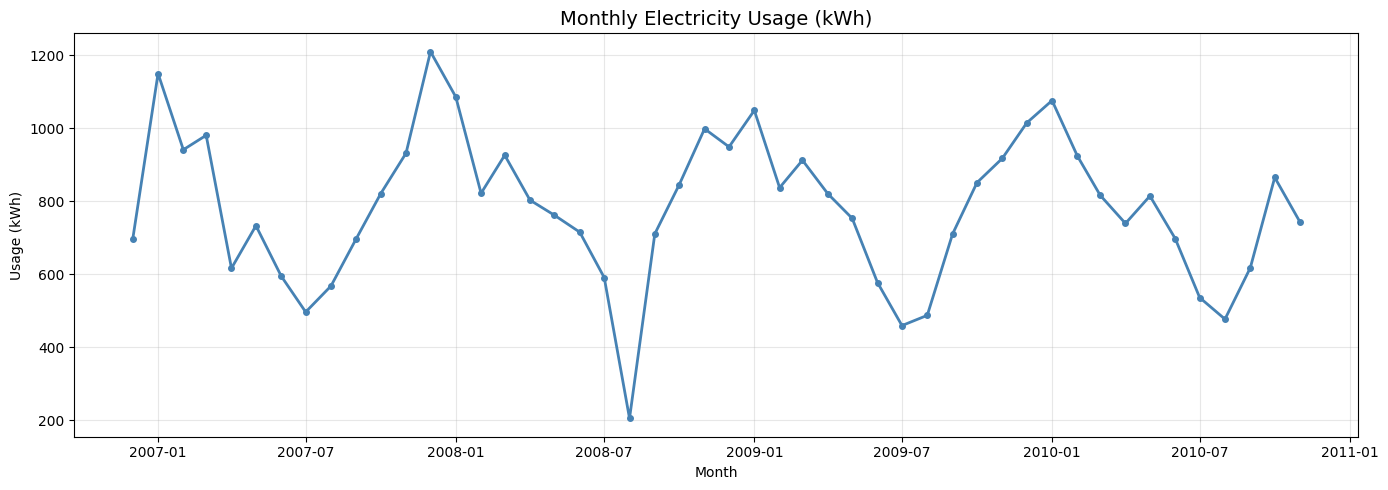

Plot saved!


In [11]:
plt.figure(figsize=(14, 5))
plt.plot(df_monthly.index, df_monthly['monthly_kwh'], color='steelblue', linewidth=2, marker='o', markersize=4)
plt.title('Monthly Electricity Usage (kWh)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Usage (kWh)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../data/monthly_usage_plot.png')
plt.show()
print("Plot saved!")

In [12]:
# Save daily cleaned data
df_daily.to_csv('../data/cleaned_daily.csv')

# Save monthly cleaned data (this is what the model will use)
df_monthly.to_csv('../data/cleaned_monthly.csv')

print("Cleaned data saved!")
print("Files saved:")
print("  → data/cleaned_daily.csv")
print("  → data/cleaned_monthly.csv")

Cleaned data saved!
Files saved:
  → data/cleaned_daily.csv
  → data/cleaned_monthly.csv
